In [1]:
import geopandas
import pandas
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

shapefile_dir = '/home/idies/workspace/21cc/Data/Census/Shapefiles/TIGER/'
new_districts_dir = '/home/idies/workspace/21cc/raddick/gerrymandering/new-districts/'

state_name = 'New Hampshire'
state_num = 33
nDistricts = 2

district_color_cycle = ['black', 'red', 'green', 'orange', 'cyan', 'yellow', 'pink', 'gray', 'lime', 'navajowhite', 'cornflowerblue', 'darkseagreen', 'thistle', 'tomato', 'silver', 'blueviolet', 'olive', 'peru', 'dodgerblue']
district_color_cycle += district_color_cycle
district_color_cycle += district_color_cycle
the_legend_size = 16
the_annotation_size = 8


print('ok')


ok


In [2]:
new_districts_df = pandas.read_csv(new_districts_dir+'new-districts-1-to-7.csv')


nh_tracts_gdf = geopandas.read_file(shapefile_dir+'2020/TRACT/tl_2020_{0:02d}_tract.shp'.format(state_num))

nh_tracts_gdf.loc[:, 'GEOID'] = nh_tracts_gdf['GEOID'].apply(lambda x: '1400000US'+x)
nh_tracts_gdf = nh_tracts_gdf[nh_tracts_gdf['GEOID'].apply(lambda x: '1400000US{0:02d}'.format(state_num) in x)]
nh_tracts_gdf = nh_tracts_gdf.set_index('GEOID')


new_districts_df = new_districts_df[new_districts_df['GEOID'].apply(lambda x: '1400000US{0:02d}'.format(state_num) in x)]
new_districts_df = new_districts_df.set_index('GEOID')

nh_tracts_gdf = nh_tracts_gdf.join(new_districts_df)
nh_tracts_gdf = nh_tracts_gdf[[x for x in nh_tracts_gdf.columns if x != 'geometry']+['geometry']]

cd119_nh_gdf = geopandas.read_file(shapefile_dir+'2025/CD/tl_2025_{0:02d}_cd119.shp'.format(state_num))

print('Got districts for {0:,.0f} census tracts'.format(len(nh_tracts_gdf)))


Got districts for 350 census tracts


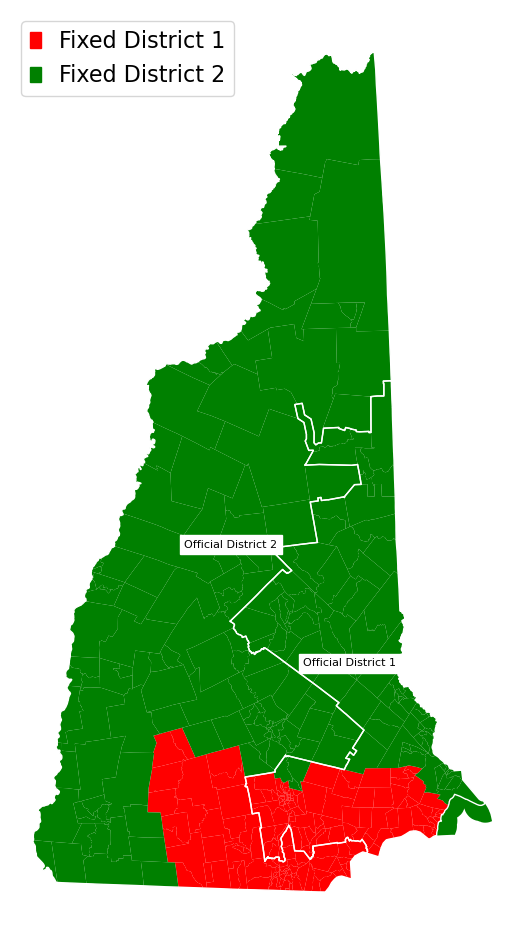

In [13]:
fig, ax = plt.subplots(1,1,figsize=(8,12))

for i in range (1, nDistricts+1):
    nh_tracts_gdf[nh_tracts_gdf['new_district'] == i].plot(ax=ax, color=district_color_cycle[i])

legend_list = []
for i in range(1,nDistricts+1):
    legend_list.append(mpatches.Patch(color=district_color_cycle[i], label='Fixed District {0:,.0f}'.format(i)))
ax.legend(handles=legend_list, fontsize=the_legend_size, loc='upper left', handlelength=0.5)


cd119_nh_gdf[cd119_nh_gdf['GEOIDFQ'] != '5001900US33ZZ'].plot(ax=ax, color='none', edgecolor='white')

for ix, thisrow in cd119_nh_gdf[cd119_nh_gdf['GEOIDFQ'] != '5001900US33ZZ'].iterrows():
    centerpoint = [thisrow.geometry.centroid.x, thisrow.geometry.centroid.y]
    annotator = 'Official District {0:}'.format(thisrow['NAMELSAD'][-1])
    ax.annotate(annotator, centerpoint, 
                 color='black', backgroundcolor='white', ha='center', va='center', 
                 fontsize=the_annotation_size)
plt.axis('off')

#plt.show()
plt.savefig('maps/new-hampshire-new-districts.png', format='png', dpi=300)

In [11]:
#cd119_nh_gdf